In [1]:
import os
import sys
from pathlib import Path


def _find_scp_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "cells").is_dir() and (p / "run_pipeline.py").is_file():
            return p
    return start


repo_root = Path(os.environ.get("SCP_ROOT") or _find_scp_root(Path.cwd())).resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from modules.analysis import sst_self_inh as sst


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


--No graphics will be displayed.


In [2]:
# Paths aligned to the current pipeline
src_path = repo_root / "external_data" / "bio_cell_output" / "pyrFiringRateAvg.csv"
out_dir = repo_root / "external_data" / "bio_cell_output"
time_col = "Time"
rate_col = "AvgFiringRate"

assert src_path.is_file(), f"Missing source curve: {src_path}"
out_dir.mkdir(parents=True, exist_ok=True)

# syn_groups/*.json uses source.path relative to repo_root, e.g.
# external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau10ms_delay50ms.csv


In [3]:
# Inspect the PN curve
info = sst.inspect_pn_csv(src_path, time_col=time_col, rate_col=rate_col)


=== PN CSV Inspection ===
Path: /home/hrbncv/SCP/external_data/bio_cell_output/pyrFiringRateAvg.csv
Columns: ['Time', 'AvgFiringRate']
Detected time column index: 0  (Time)
Detected rate column index: 1  (AvgFiringRate)
Time unit guess: s | dt_ms≈ 5.0239
Time span: -0.5 -> 0.55 (s)
Negative time samples: 100
Suggested source.bin_ms: 5.0239
Rate stats (Hz): min=1.764, max=8.841, median=2.378
First rows:
     Time  AvgFiringRate
-0.500000       1.832524
-0.494976       1.777913
-0.489952       1.910059
-0.484928       1.856796
-0.479904       1.763754


In [4]:
# Show the inspection dictionary
info


{'df':          Time  AvgFiringRate
 0   -0.500000       1.832524
 1   -0.494976       1.777913
 2   -0.489952       1.910059
 3   -0.484928       1.856796
 4   -0.479904       1.763754
 ..        ...            ...
 205  0.529904       4.842907
 206  0.534928       4.598166
 207  0.539952       4.906284
 208  0.544976       4.745146
 209  0.550000       4.746494
 
 [210 rows x 2 columns],
 'time_idx': 0,
 'rate_idx': 1,
 'time_unit': 's',
 'dt_ms': 5.023923000000041}

In [5]:
# Optional: save a simple (non-delayed) GABAB-adjusted curve
# tau_s = 0.05
# init_mode = "match"
# t, r = sst.load_curve(src_path, time_col=time_col, rate_col=rate_col)
# dt_s = sst.infer_dt_s(t)
# I, _ = sst.apply_gabab_simple(r, dt_s, tau_s, init=init_mode, alpha=1.0)
# out_path = out_dir / f"{src_path.stem}_gabab_tau{int(round(tau_s*1000))}ms.csv"
# sst.save_curve_csv(out_path, t, I, time_col=time_col, rate_col=rate_col)
# print("Wrote:", out_path)


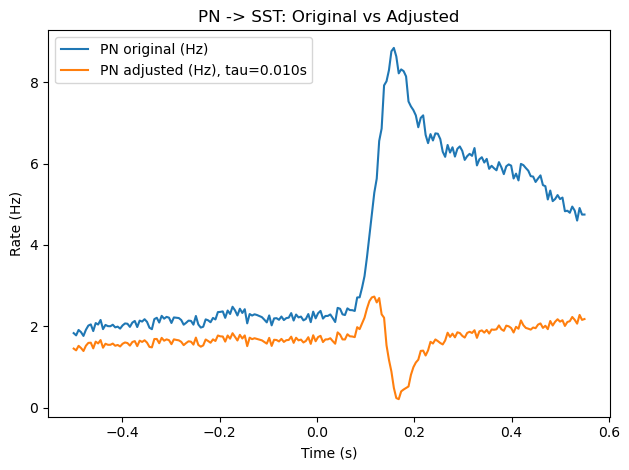

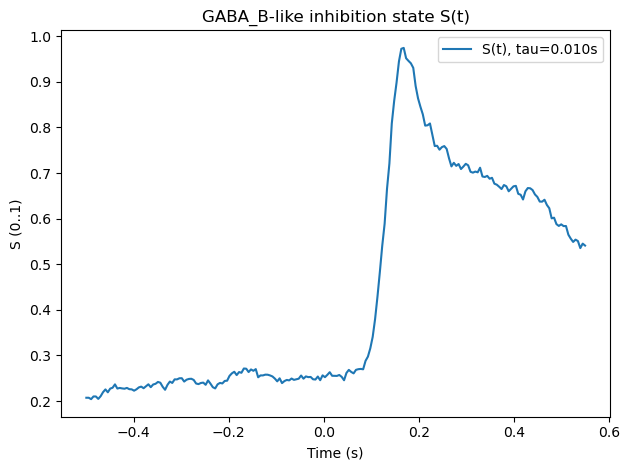

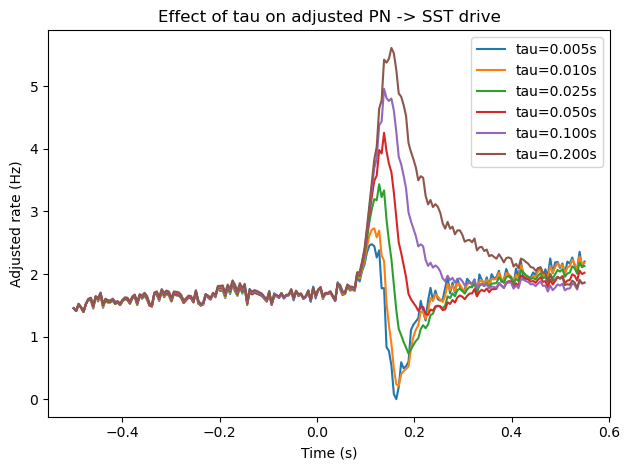

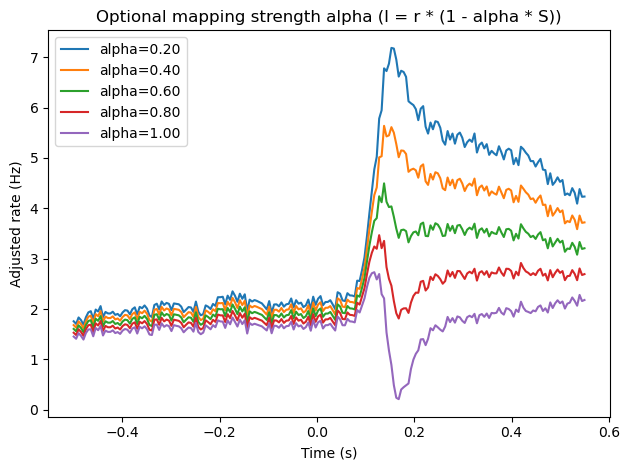

In [6]:
# --- PN -> SST (advisor spec) visualization ---
# Plots: original vs adjusted; S(t); tau sweep; optional alpha sweep
# NOTE: time is in seconds in the CSV, rate is in Hz.

# ---------- Config ----------
baseline_tau_s = 0.01            # main time constant (seconds)
init_mode = "match"              # "match" (S0=r_norm(0)) or "zero"
tau_sweep = [0.005, 0.01, 0.025, 0.05, 0.1, 0.2]
SHOW_ALPHA_SWEEP = True         # set True to view optional alpha sweep
alpha_sweep = [0.2, 0.4, 0.6, 0.8, 1.0]
use_percentile_norm = False      # set True to normalize by 99th percentile
pctl = 99.0

# ---------- Load ----------
t, r = sst.load_curve(src_path, time_col=time_col, rate_col=rate_col)

simple_results = sst.plot_gabab_simple_suite(
    t,
    r,
    baseline_tau_s=baseline_tau_s,
    init_mode=init_mode,
    tau_sweep=tau_sweep,
    show_alpha_sweep=SHOW_ALPHA_SWEEP,
    alpha_sweep=alpha_sweep,
    robust_norm=use_percentile_norm,
    pctl=pctl,
    title_prefix="PN -> SST",
)


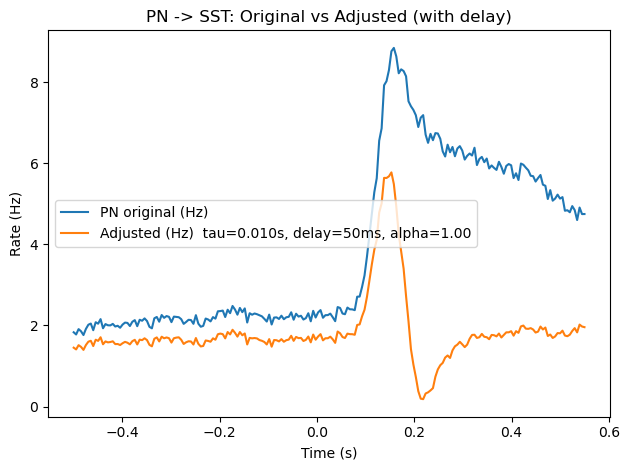

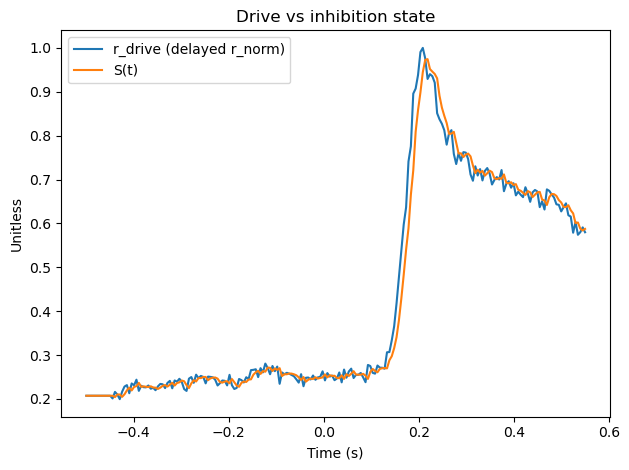

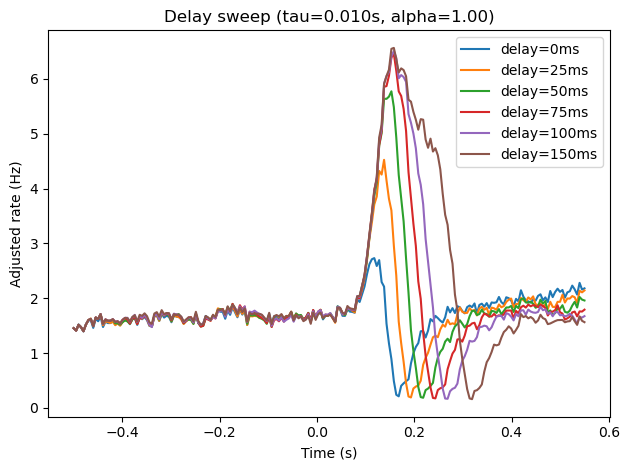

In [7]:
# --- PN -> SST with delay (matches pn_exc_gabab defaults) ---
# Equations:
#   r_norm = r / r_ref
#   dS/dt = (r_drive - S)/tau, where r_drive is r_norm delayed by delay_ms
#   I = r * (1 - alpha * S)

# ---------- Config ----------
# Baseline settings for single-trace view
# Default values match pn_exc_gabab.json

tau_s = 0.01             # seconds (10 ms)
delay_ms = 50.0          # milliseconds
alpha = 1.0              # 1.0 matches advisor mapping; <1 weakens suppression
init_mode = "match"      # "match" (S0=r_norm(0)) or "zero"

# Normalization options
use_percentile_norm = False
pctl = 99.0

# Sweep of delay values (ms) to visualize effect
delay_sweep_ms = [0.0, 25.0, 50.0, 75.0, 100.0, 150.0]

# Save the adjusted trace (using the single delay_ms baseline above)
SAVE = False

# ---------- Load ----------
t, r = sst.load_curve(src_path, time_col=time_col, rate_col=rate_col)

delayed_results = sst.plot_gabab_delayed_suite(
    t,
    r,
    tau_s=tau_s,
    delay_ms=delay_ms,
    alpha=alpha,
    init_mode=init_mode,
    robust_norm=use_percentile_norm,
    pctl=pctl,
    delay_sweep_ms=delay_sweep_ms,
    title_prefix="PN -> SST",
)

# ---------- Save (optional) ----------
if SAVE:
    out_name = f"{src_path.stem}_gabab_tau{int(round(tau_s*1000))}ms_delay{int(round(delay_ms))}ms.csv"
    out_path = out_dir / out_name
    sst.save_curve_csv(out_path, t, delayed_results["I_base"], time_col=time_col, rate_col=rate_col)
    print("Wrote:", out_path)
    try:
        print("syn_groups source.path:", out_path.relative_to(repo_root))
    except ValueError:
        pass


# GABAB history vs trimmed comparison

This compares applying the GABAB filter on the full curve (including negative time)
vs trimming/zero-shifting first (current pipeline behavior).


In [ ]:
# --- GABAB history vs trimmed comparison ---
# This cell is set up to exaggerate the difference so it's easy to see.
import numpy as np
import matplotlib.pyplot as plt

FORCE_WORST_CASE = True

if FORCE_WORST_CASE:
    tau_cmp = 0.2       # slow inhibition -> larger divergence
    delay_cmp = 0.0
    alpha_cmp = 1.0
    init_full = "match"
    init_trim = "zero"  # ignores pre-history, worst-case difference
    robust_norm_cmp = False
    pctl_cmp = 99.0
    prehistory_window_s = None  # set (e.g., 0.1) to limit pre-history
else:
    tau_cmp = tau_s if "tau_s" in globals() else 0.01
    delay_cmp = delay_ms if "delay_ms" in globals() else 50.0
    alpha_cmp = alpha if "alpha" in globals() else 1.0
    init_full = init_mode if "init_mode" in globals() else "match"
    init_trim = init_full
    robust_norm_cmp = use_percentile_norm if "use_percentile_norm" in globals() else False
    pctl_cmp = pctl if "pctl" in globals() else 99.0
    prehistory_window_s = None

# Load full curve (may include negative time samples)
t_full, r_full = sst.load_curve(src_path, time_col=time_col, rate_col=rate_col)
if t_full.size < 2:
    raise ValueError("Curve has too few samples for comparison.")

# Optionally limit pre-history window
if prehistory_window_s is not None:
    hist_mask = t_full >= -float(prehistory_window_s)
else:
    hist_mask = np.ones_like(t_full, dtype=bool)

t_hist = t_full[hist_mask]
r_hist = r_full[hist_mask]
if t_hist.size < 2:
    raise ValueError("History window too short for comparison.")

# Version A: GABAB on full curve (pre-history), then trim/shift
mask_nonneg = t_hist >= 0.0
if not np.any(mask_nonneg):
    raise ValueError("No non-negative time samples in curve.")

dt_hist = sst.infer_dt_s(t_hist)
I_hist, S_hist, _ = sst.apply_gabab_delayed(
    r_hist,
    dt_hist,
    tau_cmp,
    delay_ms=delay_cmp,
    alpha=alpha_cmp,
    init=init_full,
    robust_norm=robust_norm_cmp,
    pctl=pctl_cmp,
)

t_pre = t_hist[mask_nonneg]
r_pre = r_hist[mask_nonneg]
I_pre = I_hist[mask_nonneg]
S_pre = S_hist[mask_nonneg]
if t_pre.size:
    t_pre = t_pre - t_pre[0]

# Version B: trim/shift first (pipeline-style), then GABAB
mask_full_nonneg = t_full >= 0.0
t_trim = t_full[mask_full_nonneg]
r_trim = r_full[mask_full_nonneg]
if t_trim.size:
    t_trim = t_trim - t_trim[0]

dt_trim = sst.infer_dt_s(t_trim)
I_trim, S_trim, _ = sst.apply_gabab_delayed(
    r_trim,
    dt_trim,
    tau_cmp,
    delay_ms=delay_cmp,
    alpha=alpha_cmp,
    init=init_trim,
    robust_norm=robust_norm_cmp,
    pctl=pctl_cmp,
)

# Plot rates
plt.figure()
plt.plot(t_trim, r_trim, label="Original (trimmed)")
plt.plot(t_pre, I_pre, label="GABAB pre-history -> trim")
plt.plot(t_trim, I_trim, label="Trim -> GABAB (pipeline)")
plt.title("GABAB history vs trimmed comparison")
plt.xlabel("Time (s)")
plt.ylabel("Rate (Hz)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot inhibition state S(t)
plt.figure()
plt.plot(t_pre, S_pre, label="S(t) pre-history -> trim")
plt.plot(t_trim, S_trim, label="S(t) trim -> GABAB")
plt.title("GABAB state comparison")
plt.xlabel("Time (s)")
plt.ylabel("S (0..1)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot difference
plt.figure()
min_len = min(t_pre.size, t_trim.size)
if min_len:
    t_common = t_trim[:min_len]
    delta = I_pre[:min_len] - I_trim[:min_len]
    plt.plot(t_common, delta, label="Delta (pre-history - trimmed)")
plt.title("Difference in adjusted rate")
plt.xlabel("Time (s)")
plt.ylabel("Delta Hz")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify differences
if min_len:
    abs_delta = np.abs(delta)
    rms = float(np.sqrt(np.mean(delta ** 2)))
    max_abs = float(np.max(abs_delta))
    mean_abs = float(np.mean(abs_delta))
    peak_ref = float(np.max(I_trim)) if np.max(I_trim) > 0 else 1.0
    rel_max = 100.0 * max_abs / peak_ref

    # Early window metrics (first 200 ms)
    early_ms = 200.0
    early_mask = t_common <= (early_ms / 1000.0)
    if np.any(early_mask):
        early_abs = float(np.mean(abs_delta[early_mask]))
        early_max = float(np.max(abs_delta[early_mask]))
    else:
        early_abs = float("nan")
        early_max = float("nan")

    print("=== GABAB history vs trimmed metrics ===")
    print(f"tau={tau_cmp:.3f}s  delay={delay_cmp:.1f}ms  alpha={alpha_cmp:.2f}")
    print(f"init_full={init_full}  init_trim={init_trim}")
    print(f"max |Δ| = {max_abs:.4f} Hz  ({rel_max:.2f}% of trimmed peak)")
    print(f"mean |Δ| = {mean_abs:.4f} Hz  rms |Δ| = {rms:.4f} Hz")
    print(f"early (<= {early_ms:.0f} ms): mean |Δ| = {early_abs:.4f} Hz, max |Δ| = {early_max:.4f} Hz")


# Multi-curve comparison (files + generated)

Use this section to plot a mixed set of precomputed curve files and newly generated
GABAB-adjusted curves with their own parameters.


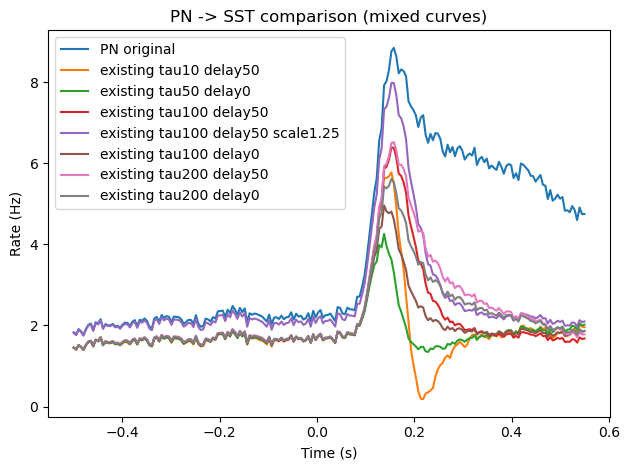

[(array([-0.5       , -0.49497608, -0.48995215, -0.48492823, -0.47990431,
         -0.47488038, -0.46985646, -0.46483254, -0.45980861, -0.45478469,
         -0.44976077, -0.44473684, -0.43971292, -0.434689  , -0.42966507,
         -0.42464115, -0.41961722, -0.4145933 , -0.40956938, -0.40454545,
         -0.39952153, -0.39449761, -0.38947368, -0.38444976, -0.37942584,
         -0.37440191, -0.36937799, -0.36435407, -0.35933014, -0.35430622,
         -0.3492823 , -0.34425837, -0.33923445, -0.33421053, -0.3291866 ,
         -0.32416268, -0.31913876, -0.31411483, -0.30909091, -0.30406699,
         -0.29904306, -0.29401914, -0.28899522, -0.28397129, -0.27894737,
         -0.27392344, -0.26889952, -0.2638756 , -0.25885168, -0.25382775,
         -0.24880383, -0.2437799 , -0.23875598, -0.23373206, -0.22870813,
         -0.22368421, -0.21866029, -0.21363636, -0.20861244, -0.20358852,
         -0.19856459, -0.19354067, -0.18851675, -0.18349282, -0.1784689 ,
         -0.17344498, -0.16842105, -0.

In [9]:
# --- Multi-curve comparison (files + generated) ---
# Each entry can either:
#   - load an existing CSV via "path"
#   - generate a new curve from the base PN curve using tau/delay/alpha
#
# Optional per-entry rate transforms (match syn_groups source settings):
#   - freq_scale: multiply rates (Hz)
#   - freq_shift: add to rates (Hz)
#   - clip_zero: clip negatives to 0 (default True)
#
# Paths can be absolute or relative to repo_root.

curve_specs = [
    {
        "label": "existing tau10 delay50",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau10ms_delay50ms.csv",
    },
    {
        "label": "existing tau50 delay0",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau50ms_delay0ms.csv",
    },
    {
        "label": "existing tau100 delay50",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau100ms_delay50ms.csv",
    },
    {
        "label": "existing tau100 delay50 scale1.25",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau100ms_delay50ms.csv",
        "freq_scale": 1.25,
    },
    {
        "label": "existing tau100 delay0",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau100ms_delay0ms.csv",
    },
    {
        "label": "existing tau200 delay50",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau200ms_delay50ms.csv",
    },
    {
        "label": "existing tau200 delay0",
        "path": "external_data/bio_cell_output/pyrFiringRateAvg_gabab_tau200ms_delay0ms.csv",
    },
    # {
    #     "label": "tau20 delay50 alpha0.7",
    #     "tau_s": 0.02,
    #     "delay_ms": 50.0,
    #     "alpha": 0.7,
    #     # "source_path": "external_data/bio_cell_output/pyrFiringRateAvg.csv",
    #     # "plot_kwargs": {"linestyle": "--"},
    # },
]

SHOW_ORIGINAL = True
ORIGINAL_LABEL = "PN original"

DEFAULT_TAU_S = 0.01
DEFAULT_DELAY_MS = 50.0
DEFAULT_ALPHA = 1.0

sst.plot_multi_curve_comparison(
    curve_specs,
    src_path=src_path,
    repo_root=repo_root,
    time_col=time_col,
    rate_col=rate_col,
    show_original=SHOW_ORIGINAL,
    original_label=ORIGINAL_LABEL,
    default_tau_s=DEFAULT_TAU_S,
    default_delay_ms=DEFAULT_DELAY_MS,
    default_alpha=DEFAULT_ALPHA,
)


# Legacy exponential filter (optional)

This section preserves the older exponential suppression rule for reference only.
The current pipeline uses the ODE-based GABAB filter above.


In [10]:
RUN_LEGACY = False  # set True to run the legacy exponential filter below


In [11]:
if RUN_LEGACY:
    t, r = sst.load_curve(src_path, time_col=time_col, rate_col=rate_col)

    legacy_params = {
        "stim_delay_ms": 100.0,
        "beta": 0.5,
        "tau_ms": 200.0,
    }

    inh_curve = sst.apply_legacy_exponential(
        t,
        r,
        stim_delay_ms=legacy_params["stim_delay_ms"],
        beta=legacy_params["beta"],
        tau_ms=legacy_params["tau_ms"],
    )

    SAVE_LEGACY = False
    if SAVE_LEGACY:
        out_name = (
            f"{src_path.stem}_legacy_beta{legacy_params['beta']}_"
            f"tau{int(legacy_params['tau_ms'])}ms_delay{int(legacy_params['stim_delay_ms'])}ms.csv"
        )
        out_path = out_dir / out_name
        sst.save_curve_csv(out_path, t, inh_curve, time_col=time_col, rate_col=rate_col)
        print("Wrote:", out_path)


In [12]:
if RUN_LEGACY:
    sst.plot_legacy_curve(t, r, inh_curve)
